In [1]:
%reset -f
%matplotlib inline
%config InlineBackend.figure_format='retina'
import json
import math
import numpy as np
import matplotlib.pyplot as plt

def print_json(obj, *filter_keys):
    if filter_keys:
        filter_keys = set(filter_keys)
        obj = {k: v for k, v in obj.items() if k in filter_keys}
    print(json.dumps(obj, indent=2))

# GOSSIP REACH MODEL

This is a simple model of epidemic gossip propagation through the network, with and without deduplication cache for recently seen messages. The key insights are the number of nodes informed and peak traffic bursts. This does not concern broadcast gossips because their propagation process is trivial.

The important metric to consider in protocol design is the rx/tx message load per node from the protocol core itself, as opposed to application-related messages. The protocol should not require nodes to process a nontrivial number of auxiliary messages to stay efficient. At the same time, the protocol must be able to detect consensus violations and repair them quickly without a central authority, and without any of the nodes sharing the full view of the allocation table. These requirements are very hard to reconcile.

The original design proposal relied on broadcast gossips only, where each node would send gossip messages to the broadcast subject (which is called "broadcast" only at the Cyphal level, while at L3/L2 IP networking it is actually a multicast group that all Cyphal nodes join), and every node receives every message. The scalability picture is terrible -- given mean broadcast rate $r_\text{broadcast}$ \[msg/s\], a $N$-node network generates $(N-1) \cdot r_\text{broadcast}$ of arrivals per node. While the load scale can be mitigated by reducing the broadcast frequency to sub-hertz rates, this is at odds with reaching consensus quickly.

A traditional solution is some form of epidemic gossip propagation, where each node maintains a randomly sampled set of other nodes (information on how to reach them), called its *peer set* of size $k$. Instead of broadcasting, each gossip message is sent to a small random subset of size $d$ of the peer set; the size of that set is called the outdegree of the gossip message. Messages sent in such way have a predefined TTL (time to live, maximum number of forwards), or the maximum hop count $L$, defined as $L=\text{TTL+1}$. In addition, equality comparison is defined on such gossip messages to allow nodes to discontinue propagation of messages that have been seen recently; the structure implementing such deduplication is called the *dedup cache*.

The gossip coverage models are fairly simple mean-field models that reveal the key trade-offs involved. It can be seen, for example, that while the cache slightly reduces the reach of each epidemic gossip message under random peer selection (since propagation ceases once the message is routed back to a peer that has already seen it), it also significantly reduces the peak network load.

By itself, plain epidemic gossip is not very useful for protocol design, but it is an important building block that is used in the later sections.

In [14]:
def gossip_coverage_with_dedup(N, d, L):
    """
    Returns the expectation of the total number of nodes reached by the last hop, where each node drops gossips
    already seen (i.e., not forwarded if seen earlier, called gossip deduplication).
    Also returns the network packet load in the last hop.
    
    Assuming perfect deduplication (every seen gossip is dropped); imperfection slightly increases reach and
    the forwaring load but the difference is insignificant.
    
    Assuming each node picks a random peer per transmit; implying assumption of reasonably uniform peer sampling.

    N: number of nodes in the network
    d: unicast gossip outdegree (number of destinations per hop)
    L: gossip message TTL (forward hop count)
    """
    S = 1  # informed nodes (nodes that received the gossip), incl. the origin
    A = 1  # expansion per hop (nodes that became informed in that hop), initially just the origin node
    for hop in range(L):
        M = d * A  # number of transmissions across all nodes at this hop
        # Model spread A_h+1 as balls into bins / coupon's collector problem:
        # - https://en.wikipedia.org/wiki/Balls_into_bins_problem
        # - https://en.wikipedia.org/wiki/Coupon_collector%27s_problem
        A_next = (N - S) * (1 - np.exp(-M / (N-1)))
        S_next = S + A_next
        S, A = S_next, A_next
        #print(f"hop {hop}: reached {S: 4.0f}/{N} nodes so far, contacted {A: 3.0f} new nodes this hop")
    return int(S), int(d * A)


def gossip_coverage_no_dedup(N, d, L):
    """
    The counterpart for the coverage-with-dedup model that assumes that nodes do not deduplicate seen gossips.
    Simple algebraic closed forms exist, but we use this iterative model for parity with the dedup model.
    In comparison to the dedup-enabled model, this one shows exponential traffic growth for d>1.
    """
    S = 1        # unique informed nodes, includes origin
    copies = 1   # copies at current frontier (origin copy initially)
    M_last = 0
    for hop in range(L):
        M = d * copies                   # all copies forward
        M_last = M
        A_next = (N - S) * (1.0 - np.exp(-M / (N - 1)))  # see the other model
        S += A_next
        copies = M                       # next hop has one copy per tx
    return int(S), int(M_last)


print(gossip_coverage_with_dedup(300, 2, 10))
print(gossip_coverage_no_dedup(300, 2, 10))

(226, 32)
(299, 1024)


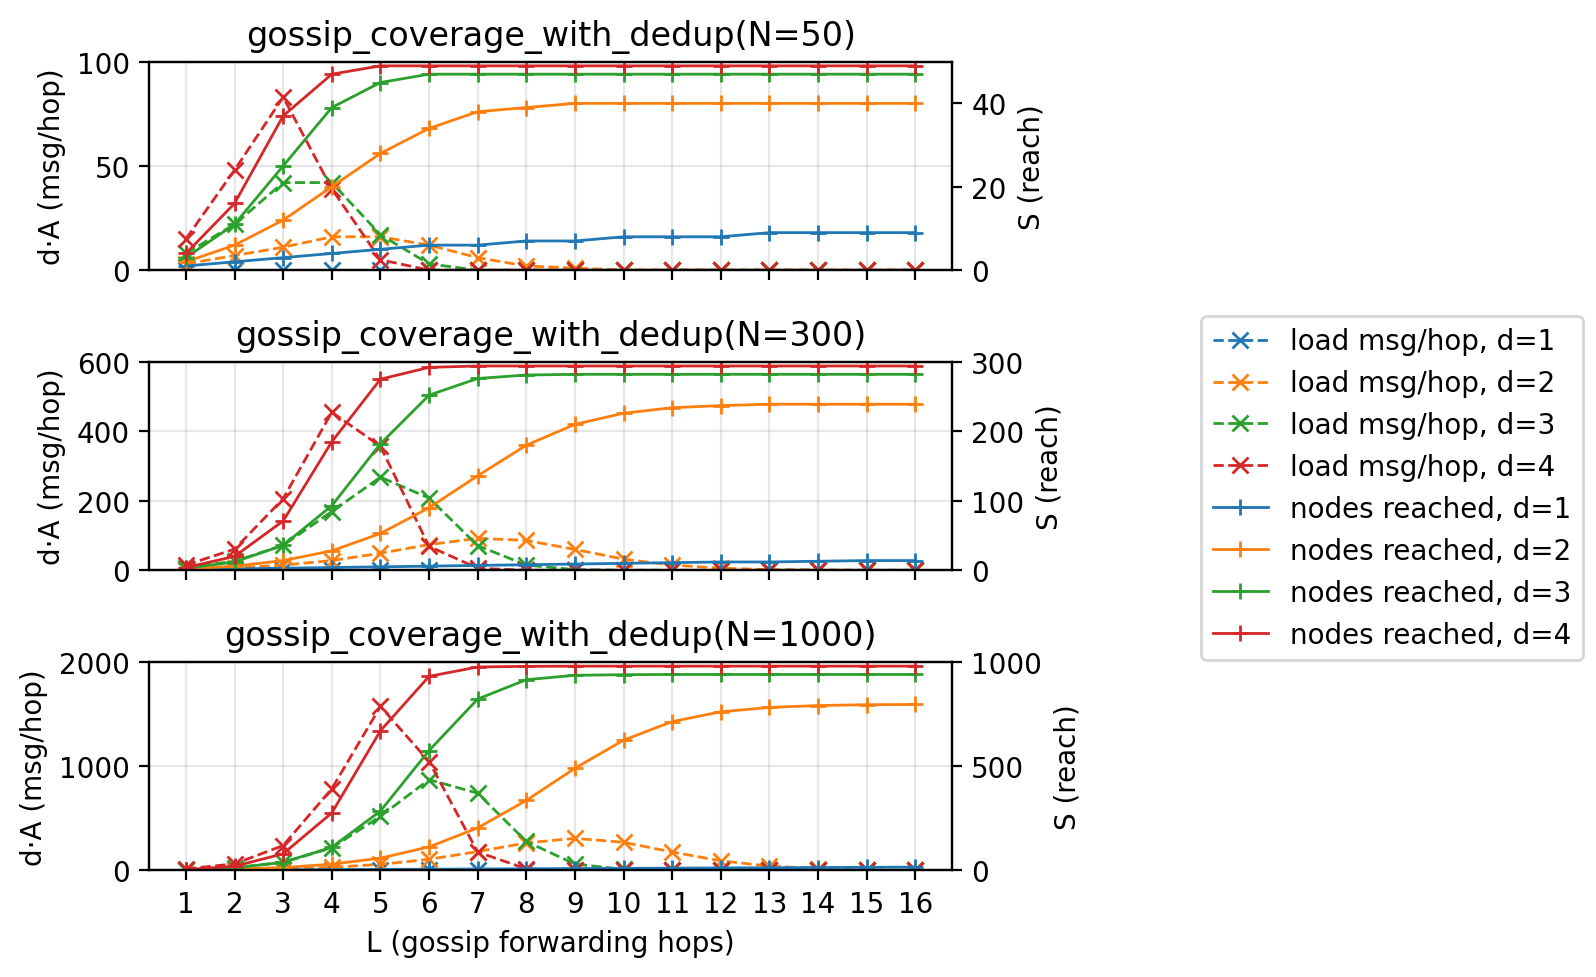

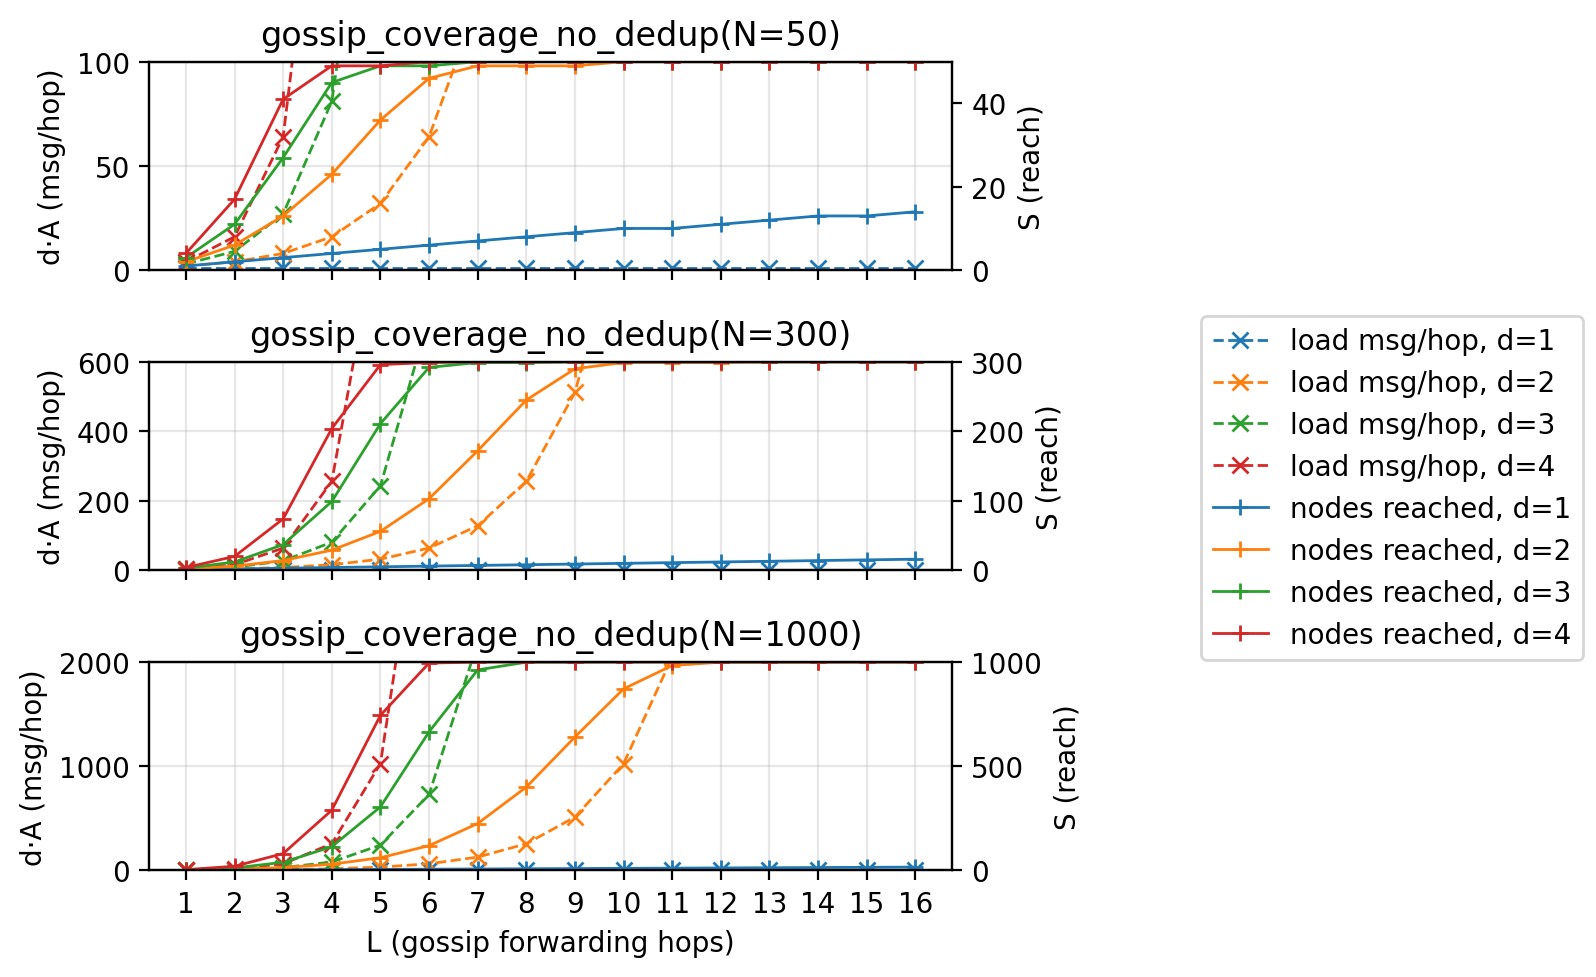

In [15]:
def plot_gossip_coverage(Ns, ds, model, L_max=16):
    Ls = list(range(1, L_max+1))
    fig, axes = plt.subplots(len(Ns), 1, figsize=(8, 5), sharex=True)
    cov_axes = []
    for ax_load, N in zip(axes, Ns):
        ax_cov = ax_load.twinx()
        cov_axes.append(ax_cov)
        for d in ds:
            results = [model(N, d, L) for L in Ls]
            coverage = [r[0] for r in results]
            load = [r[1] for r in results]
            ax_load.plot(
                Ls,
                load,
                linestyle="--",
                marker="x",
                linewidth=1,
                label=f"load msg/hop, d={d}",
            )
            ax_cov.plot(
                Ls,
                coverage,
                marker="+",
                linewidth=1,
                label=f"nodes reached, d={d}",
            )
    
        ax_load.set_title(f"{model.__name__}(N={N})")
        ax_load.set_ylabel("d·A (msg/hop)")
        ax_cov.set_ylabel("S (reach)")
        ax_load.set_ylim(0, N*2)
        ax_cov.set_ylim(0, N)
        ax_load.set_xticks(Ls)
        ax_load.grid(True, alpha=0.3)
    axes[-1].set_xlabel("L (gossip forwarding hops)")
    handles_load, labels_load = axes[0].get_legend_handles_labels()
    handles_cov, labels_cov = cov_axes[0].get_legend_handles_labels()
    fig.legend(
        handles_load + handles_cov,
        labels_load + labels_cov,
        loc="center right",
    )
    fig.tight_layout(rect=[0, 0, 0.7, 1])
    plt.show()

for model in (gossip_coverage_with_dedup, gossip_coverage_no_dedup):
    plot_gossip_coverage(Ns=[50, 300, 1000], ds=[1, 2, 3, 4], model=model)

It can be seen that modest TTL≈10 ($L\approx11$) is suitable even for large networks up to N≈1k, while outdegree $d$ should not exceed 2 because higher values do not materially increase reach while they do increase the burst traffic.

# GOSSIP ARRIVAL LOAD

This model explores the message load experienced by an average node triggered by a single epidemic gossip, assuming that the dedup cache is present (configurations without the dedup cache are unviable load-wise so not explored further). This can be used to derive protocol parameters given specific processing load caps per node in arrivals per second.

The capacity of the dedup cache scales with the maximum number of concurrent gossips in flight; nodes do not have to agree on a particular number since it does not affect interoperability but rather caps the peak gossip traffic. Resource-rich nodes may and should implement larger caches. Storing the cache in a simple linear array in memory means that capacities above 16~32 might be less desirable in small nodes because at that point linear lookup becomes inefficient, calling for more sophisticated log-complexity containers.

In [17]:
def gossip_arrival_rate_with_dedup(N, d, L, r):
    """
    Model of the gossip message arrival load PER NODE as a function of epidemic parameters.
    This model informs the choice of periodic gossip parameters.
    
    N: node count
    d: outdegree
    L: number of forwarding hops (same semantics as range(L))
    r: new gossip origination rate per node [gossips/s/node, Hz/node]

    Returns:
        rx_per_node_hz: total unicast arrivals per node [msg/s]
        reached_expected: expected unique reached nodes after L hops
        tx_per_origin: expected total unicast tx for one originated gossip
    """
    S = 1  # informed unique nodes
    A = 1  # newly informed on current hop frontier (origin initially)
    hop_M = []
    for hop in range(L):
        M = d * A
        hop_M.append(M)
        if N > 1:
            A_next = (N - S) * (1.0 - math.exp(-M / (N - 1)))
        else:
            A_next = 0.0
        S += A_next
        A = A_next
    tx_per_origin = sum(hop_M)
    hop_rx_per_node_hz = [r * m for m in hop_M]
    rx_per_node_hz = sum(hop_rx_per_node_hz)
    return rx_per_node_hz, int(S), tx_per_origin

gossip_arrival_rate_with_dedup(300, 2, 16, 1)

(479.5548590762277, 239, 479.5548590762277)

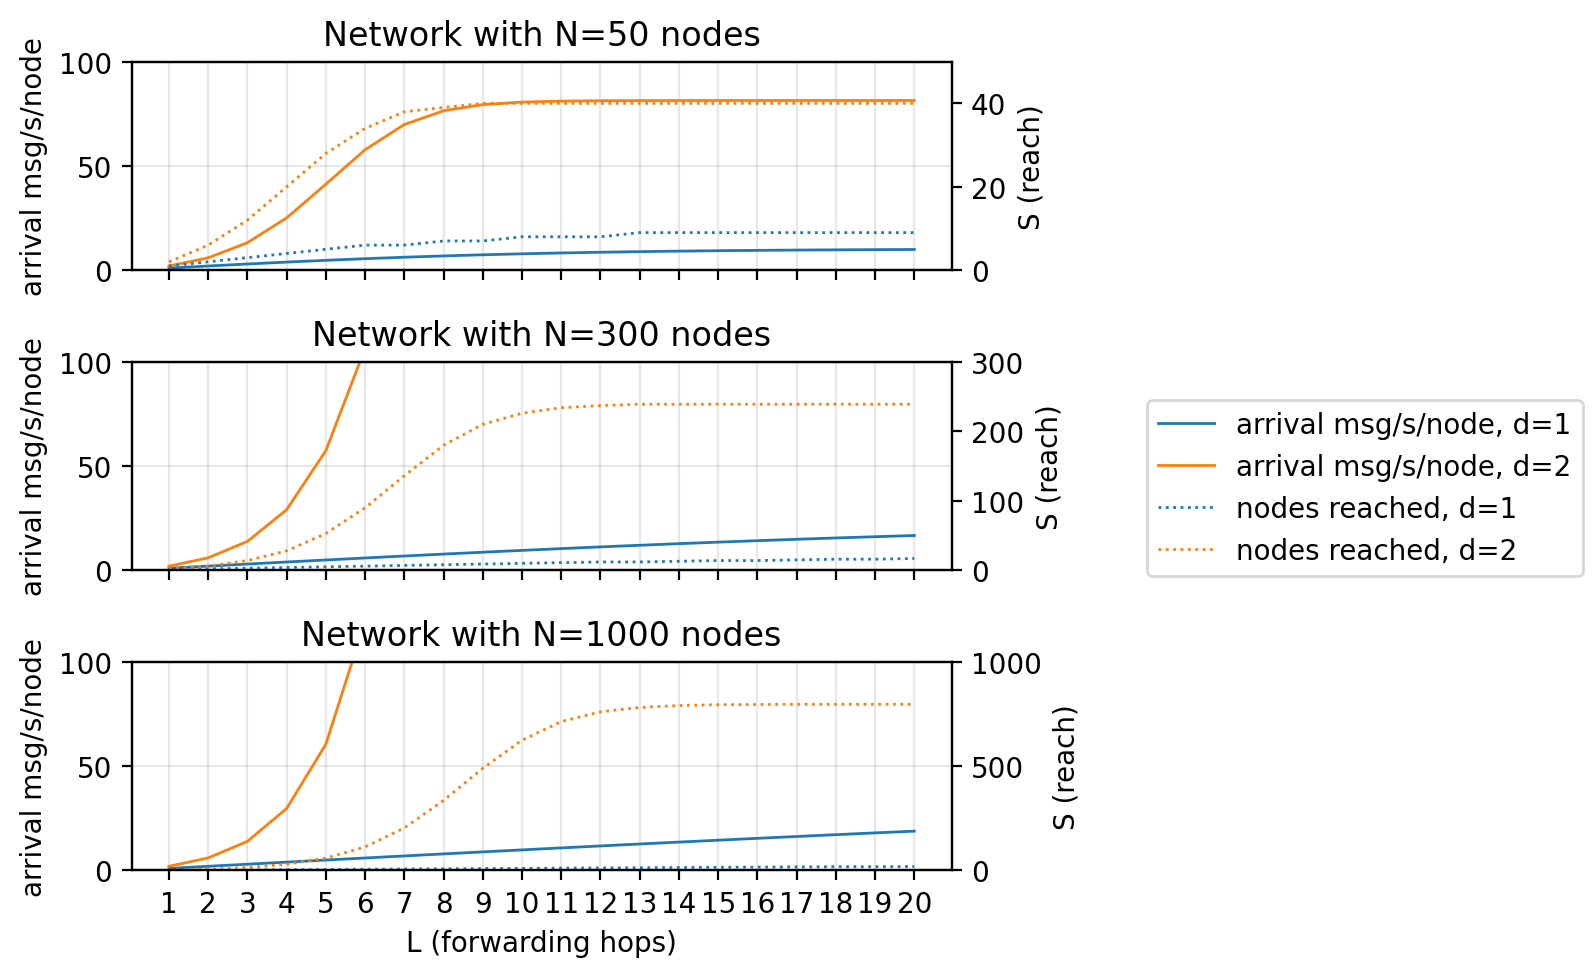

In [18]:
def plot_gossip_arrival_rate(Ns, ds, model, rate=1, L_max=20):
    Ls = list(range(1, L_max+1))
    fig, axes = plt.subplots(len(Ns), 1, figsize=(8, 5), sharex=True)
    cov_axes = []
    for ax_load, N in zip(axes, Ns):
        ax_cov = ax_load.twinx()
        cov_axes.append(ax_cov)
        for d in ds:
            results = [model(N=N, d=d, L=L, r=rate) for L in Ls]
            coverage = [r[1] for r in results]
            load = [r[0] for r in results]
            ax_load.plot(
                Ls,
                load,
                linewidth=1,
                label=f"arrival msg/s/node, d={d}",
            )
            ax_cov.plot(
                Ls,
                coverage,
                linestyle=":",
                linewidth=1,
                label=f"nodes reached, d={d}",
            )
        ax_load.set_title(f"Network with N={N} nodes")
        ax_load.set_ylabel("arrival msg/s/node")
        ax_cov.set_ylabel("S (reach)")
        ax_load.set_ylim(0, 100)
        ax_cov.set_ylim(0, N)
        ax_load.set_xticks(Ls)
        ax_load.grid(True, alpha=0.3)
    axes[-1].set_xlabel("L (forwarding hops)")
    handles_load, labels_load = axes[0].get_legend_handles_labels()
    handles_cov, labels_cov = cov_axes[0].get_legend_handles_labels()
    fig.legend(
        handles_load + handles_cov,
        labels_load + labels_cov,
        loc="center right",
    )
    fig.tight_layout(rect=[0, 0, 0.7, 1])
    plt.show()

plot_gossip_arrival_rate(Ns=[50, 300, 1000], ds=[1, 2], model=gossip_arrival_rate_with_dedup)

If pure epidemic gossips were to be used for periodic gossip transmissions, then it is necessary that the outdegree $d=1$, because this is the only case where the mean arrival load per node remains invariant over the network size N and thus does not exhibit the scalability problem seen with broadcast gossips. It is intuitively clear: if messages do not multiply during propagation, each subsequent hop is diffused over the remaining nodes; as the number of transmitting nodes increases, so does the number of potential destinations, meaning that the load expectation remains constant.

Higher $d>1$ are viable for one-off events such as when a consensus repair is needed and the brief load burst can be tolerated.

Trading off the unicast gossip transmission rate $r_\text{unicast}$ for higher TTL ($L_\text{unicast}-1$) is believed to be a sensible choice because higher TTL values provide better gossip distribution than higher origination rates given the same total arrival load. The average arrival load per node generated by unicast gossips with hop limit $L$ and origination rate $r$ is simply $L_\text{unicast} \cdot r_\text{unicast}$.

Factoring in the broadcast load, a protocol that uses broadcast plus unicast gossips would generate the average arrival load per node of:

$$
r_\text{arrival} = (N-1) \cdot r_\text{broadcast} + L_\text{unicast} \cdot r_\text{unicast}
$$

This can be made quite manageable load-wise by adjusting the rates; however, the ability of this structure to deliver relevant gossip messages where needed is limited. Broadcast gossips do not require any routing effort to be efficient, but for unicast gossips it matters; as $d$ has to be small, one can see from the plots above that epidemic unicast gossips can only reach a very small subset of nodes, meaning that existing CRDT divergences may stay dormant for potentially very long time.

There is a simple benchmark problem for the gossip protocol design. Consider a network with large number of nodes and topics. Within that network, there are nodes $N_a, N_b$, such that both have topic $A$ that is not shared by any other node, and additionally $N_b$ has topic $B$ that is not used by any other node in the network; both $A$ and $B$ happen to be allocated to the same subject $S_0$, and $A$ loses arbitration to $B$, such that the next subject chosen for $A$ in $N_b$ is $S_1$. Both nodes have a large number of other topics. We assume that there is no regular traffic on $A$ and $B$. The resulting distributed allocation table subset looks as follows:

Allocation | $N_a$         | $N_b$
-----------|---------------|---------------
$A$        | $S_0$         | $S_1$
$B$        | $\varnothing$ | $S_0$
others...  | ...           | ...

The allocation table has both a collision (both A and B occupy $S_0$) and a divergence (both $S_0$ and $S_1$ are used for A). Consider the following scale scenarios:

- If both A and B have few topics, the gossip rate of each will be high (assuming the gossip rate is constant and the gossip scheduler is ~fair). Thus, A and/or B will be gossiped by the involved nodes soon, allowing the other to notice the divergence and initiate consensus repair (more on this below).
- If only A or B have few topics, the situation is similar to the above as long as the node that has noticed the divergence/collision is able to issue a gossip message that is likely to be delivered to the other node (more on this below).
- If both A and B have a large number of topics, the collision/divergence may remain dormant for a long time.

Efficient repair of a collision or a divergence requires delivering a gossip message to a node that has exposed the conflict, which can be called a culprit node. The naive solution of sending a unicast gossip message back to the culprit has a potential scalability issue: if the culprit has offended a large set of nodes, it may receive a large set of gossips in response, which may be disturbing to resource-limited and/or real-time nodes. It is hard to directly coordinate such response in a decentralized system, but solutions exist. One such solution is referred to as the *attractor gossip*, which relies on the dedup cache introduced earlier; it is explained in the next section.

# ATTRACTOR GOSSIP MODEL

The attractor gossip provides directed gossip messages that are delivered to an arbitrary specified node, called the *attractor* node, *such that* the arrival load at the attractor is nearly constant; in particular it is mostly invariant over the network size $N$ or the number of nodes originating the directed gossip near-simultaneously $m$. The solution relies on gossip dedup caches available in every node, such that all nodes conspire to drop redundant messages without explicit hard state sharing or centralization.

This is a simple extension of the basic epidemic gossip model introduced earlier. Each attractor gossip message includes the node ID of the attractor node (usually the culprit node that triggered the consensus repair). The first hop (from the originator) is sent like an ordinary epidemic gossip to $d$ randomly selected peers from the $k$-sized local peer set. Forwarding is done only if the gossip message is not rejected by the dedup cache using one of the two rules depending on whether the forwarder has the attractor in its peer set:

- If the forwarder doesn't have the attractor in the peer set, forwarding is done as usual for epidemics ($d$ random unique peers excluding the sender).
- Otherwise, the gossip is sent directly to the attractor once. (Optionally, if the original outdegree $d>1$, it can be reduced by one and forwarded to a random peer to continue propagation, but as the model shows it has limited utility.)

The core idea of the method is that since the first hop is *never* sent directly to the attractor but rather sideways, each such gossip will pass through at least one transit node where it will be subject to deduplication, reducing the redundant arrivals at the attractor. The gossip is sent directly to the attractor on the first transit node that has it in its peer set, where the probability of that happening is $q = \frac{k}{N - 1}$. The decay of $q$ with larger N is compensated by the wider reach of the epidemic spread in large networks, which results in nearly-constant terminal arrival load (perhaps counterintuitively at first).

The model as stated has an edge case: when the number of originators $m$ is large enough to be comparable to $N$ (which may theoretically occur for very popular topics), messages are deduplicated aggressively, causing the probability of hitting a node that has the attractor in its peer set to fall quickly. This can be easily mitigated by introducing a small probability $0 < \rho \lessapprox 0.1$ of sending the attractor gossip directly to the attractor from the origin on the first hop if the attractor is in its peer set.

In [19]:
def attractor_gossip(*, N, m=1, d=2, L=10, k=12, rho=0.0):
    """
    Mean-field model of attractor gossip.

    N: Total nodes in the network, including origin and attractor.
    m: The number of near-simultaneous tx of same gossip (when multiple nodes detect divergence), usually 1.
    d: Outdegree, random fanout when attractor is not in peer set.
    L: Forwarding TTL in hops (same semantics as range(L)).
    k: Peer-set size on each node (random sample of other nodes).
    rho: Probability that a gossip originator which has the attractor in its peer set sends one direct
         gossip to it on hop 0; this counts as one of the d slots. When >0, improves attractor reachability
         under large m≲N.

    Returns:
        reached_nodes: expected informed non-attractor nodes by final hop
        attractor_hit_prob: probability that at least one informed node had attractor in peer set
        attractor_arrivals: expected total tx to attractor
        tx_per_hop_random: per-hop epidemic tx (ordinary)
        tx_per_hop_attractor: per-hop tx direct to attractor
        tx_total: total messages exchanged across all hops
        q: probability a node has attractor in peer set
    """
    # Probability that a node has the attractor in its peer set is exact for uniform size-k random peer sets.
    # Given N nodes, the probability that nobody has the attractor is (1-q)^(N-1) ≈ e^-k, so the probability
    # of attractor hit is conveniently approximated as 1-e^-k.
    q = k / (N - 1)       
    N_pool = N - 1        # all non-attractor nodes, origin included
    if not (0 < m <= N_pool) or (d < 1) or not (0 <= rho <= 1):
        raise ValueError
    # The effective branching factor (outdegree) considering propagation stop when the gossip hits
    # a node that has the attractor in its peer set. Key trade-off:
    # - larger peer set k raises q, attractor found sooner
    # - larger k lowers branching R_eff, fewer bystander nodes see the gossip
    # - larger k increases attractor arrival load as q·A per hop
    R_eff = d * (1 - q)
    # At a first glance it may seem counter-intuitive, but the number of originators m does not affect the
    # propagation dynamics that much thanks to the gossip dedup cache, assuming that all original gossips
    # are sent within a time window that is nontrivially smaller than the gossip dedup cache lifetime.
    # The first hop grows like d·m, subsequent hops multiply R_eff per hop. The key observations are:
    # - for small m, burden at the attractor grows linearly with m; but
    # - for large m, thanks to the distributed dedup cache the load grows sublinearly in m!
    S = float(m)         # informed non-attractor nodes
    A = float(m)         # frontier size (origin initially)
    hop_random = []      # per-hop epidemic tx (ordinary)
    hop_attractor = []   # per-hop tx to attractor
    forwarder_opportunities = 0.0   # expected number of post-hop-0 forwarders
    for hop in range(L):
        if hop == 0:
            # A fraction rho of originators that have the attractor as a peer use one d slot for direct send.
            U = rho * q * A
            M = (d - rho * q) * A
        else:        # Forwarders either redirect to attractor or diffuse randomly.
            U = q * A
            M = R_eff * A
            forwarder_opportunities += A
        hop_random.append(M)
        hop_attractor.append(U)
        A_next = 0.0
        if N_pool > 1:  # balls-into-bins model
            A_next = (N_pool - S) * (1.0 - math.exp(-M / (N_pool - 1)))
        S += A_next
        A = A_next

    # The final attractor hit expectation incorporates rho, which trivially disappears when rho=0,
    # resulting in the original formulation used before the introduction of rho into the model:
    # attractor_hit_prob = 1.0 - (1.0 - q) ** forwarder_opportunities
    attractor_hit_prob = 1.0 - ((1.0 - rho * q) ** m) * ((1.0 - q) ** forwarder_opportunities)
    return dict(
        reached_nodes=S,
        attractor_hit_prob=attractor_hit_prob,
        tx_per_hop_random=hop_random,
        tx_per_hop_attractor=hop_attractor,
        tx_total=sum(hop_random) + sum(hop_attractor),
        attractor_arrivals=sum(hop_attractor),
        q=q,
    )

# A basic table to get a rough idea
for N in (50, 300, 1000):
    print(f"{N=}:")
    for m in (1, int(N * 0.95)):
        print(f"\t{m=}:")
        for rho in (0.0, 0.03, 0.05):
            P = attractor_gossip(N=N, m=m, rho=rho)
            arrivals = P['attractor_arrivals']
            P_hit = P['attractor_hit_prob']
            tx = P['tx_total']
            print(f"\t\tρ={rho:.3f}: {arrivals=:.1f} {P_hit=:.1f} {tx=:05.0f}")

N=50:
	m=1:
		ρ=0.000: arrivals=6.9 P_hit=1.0 tx=00051
		ρ=0.030: arrivals=6.9 P_hit=1.0 tx=00051
		ρ=0.050: arrivals=6.9 P_hit=1.0 tx=00051
	m=47:
		ρ=0.000: arrivals=0.4 P_hit=0.4 tx=00097
		ρ=0.030: arrivals=0.8 P_hit=0.6 tx=00097
		ρ=0.050: arrivals=1.0 P_hit=0.7 tx=00097
N=300:
	m=1:
		ρ=0.000: arrivals=7.8 P_hit=1.0 tx=00381
		ρ=0.030: arrivals=7.8 P_hit=1.0 tx=00381
		ρ=0.050: arrivals=7.8 P_hit=1.0 tx=00381
	m=285:
		ρ=0.000: arrivals=0.5 P_hit=0.4 tx=00594
		ρ=0.030: arrivals=0.8 P_hit=0.6 tx=00594
		ρ=0.050: arrivals=1.1 P_hit=0.7 tx=00594
N=1000:
	m=1:
		ρ=0.000: arrivals=5.6 P_hit=1.0 tx=00932
		ρ=0.030: arrivals=5.6 P_hit=1.0 tx=00932
		ρ=0.050: arrivals=5.6 P_hit=1.0 tx=00932
	m=950:
		ρ=0.000: arrivals=0.5 P_hit=0.4 tx=01984
		ρ=0.030: arrivals=0.9 P_hit=0.6 tx=01984
		ρ=0.050: arrivals=1.1 P_hit=0.7 tx=01984


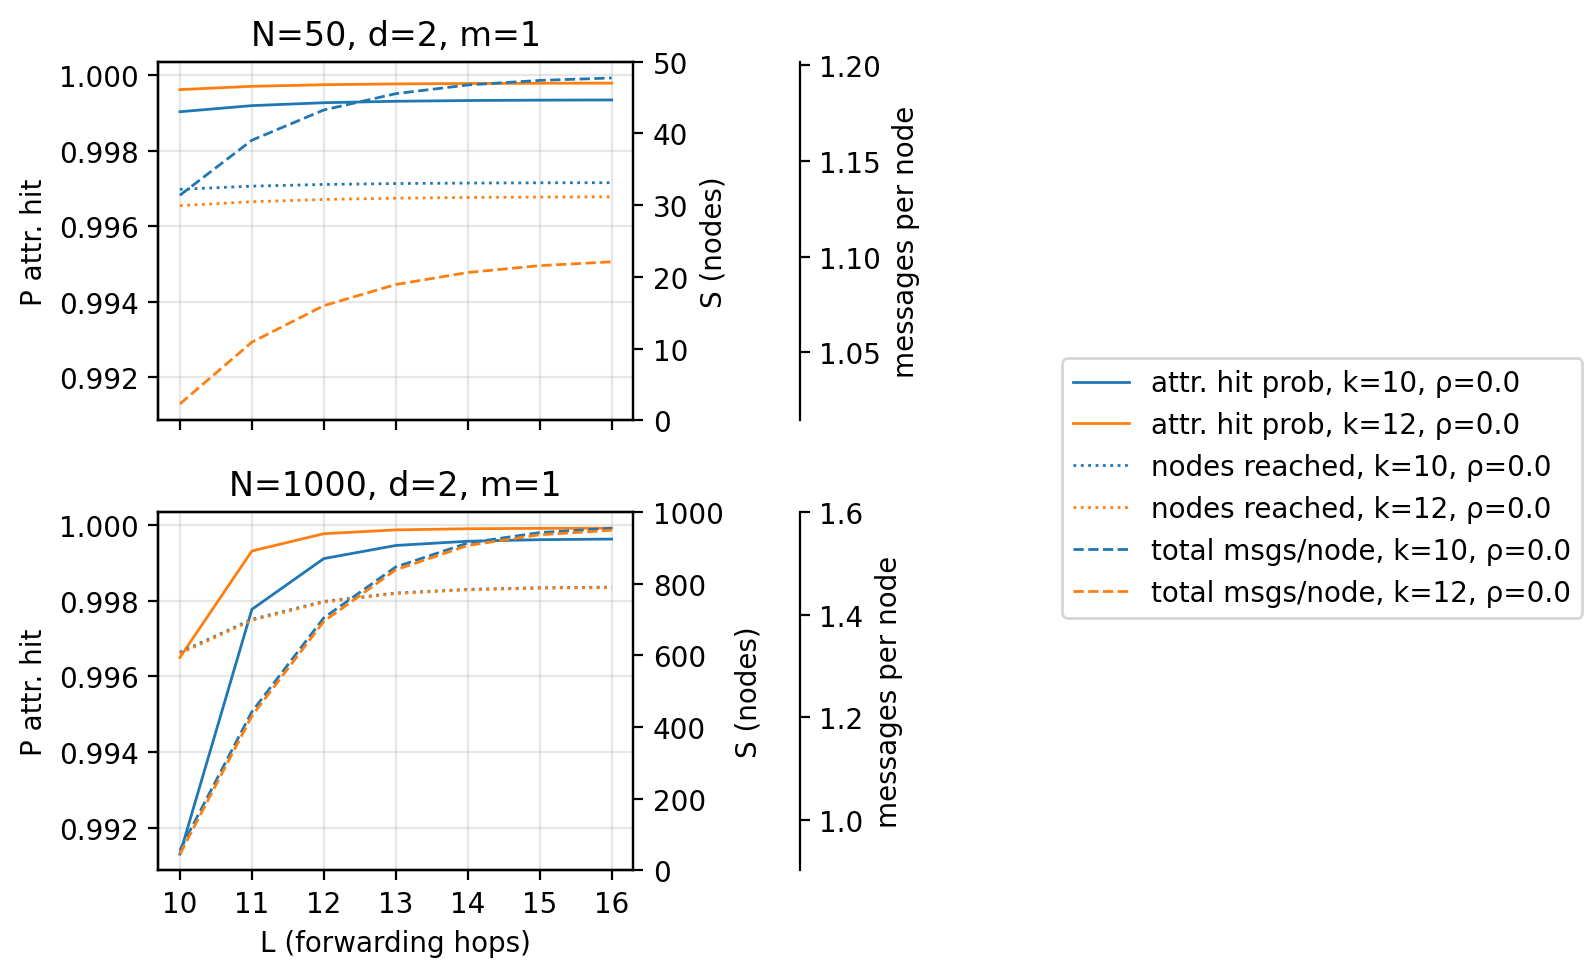

In [20]:
def plot_attractor_in_hops(Ns, ks, Ls, rhos, d=2, m=1):
    fig, axes0 = plt.subplots(len(Ns), 1, figsize=(8, 5), sharex=True, sharey=True)
    axes1 = []
    axes2 = []
    for ax0, N in zip(axes0, Ns):
        ax1 = ax0.twinx()
        ax2 = ax0.twinx()
        ax2.spines["right"].set_position(("outward", 60))
        axes1.append(ax1)
        axes2.append(ax2)
        ax0.set_title(f"N={N}, d={d}, m={m}")
        for k in ks:
            for rho in rhos:
                results = [attractor_gossip(N=N, k=k, d=d, m=m, L=L, rho=rho) for L in Ls]
                options = f"k={k}, ρ={rho}"
                ax0.plot(
                    Ls,
                    [r["attractor_hit_prob"] for r in results],
                    linewidth=1,
                    label=f"attr. hit prob, {options}",
                )
                ax1.plot(
                    Ls,
                    [r["reached_nodes"] for r in results],
                    linestyle=":",
                    linewidth=1,
                    label=f"nodes reached, {options}",
                )
                ax2.plot(
                    Ls,
                    [(r["tx_total"] / N) for r in results],
                    linestyle="--",
                    linewidth=1,
                    label=f"total msgs/node, {options}",
                )
        ax0.set_ylabel("P attr. hit")
        ax0.set_xticks(Ls)
        ax0.grid(True, alpha=0.3)
        ax1.set_ylabel("S (nodes)")
        ax1.set_ylim(0, N)
        ax2.set_ylabel("messages per node")
    axes0[-1].set_xlabel("L (forwarding hops)")
    handles, labels = None, None
    for ax in (axes0, axes1, axes2):
        h, l = ax[0].get_legend_handles_labels()
        handles = h if handles is None else (handles + h)
        labels  = l if labels is None else (labels + l)
    fig.legend(handles, labels, loc="center right")
    fig.tight_layout(rect=[0, 0, 0.6, 1])
    plt.show()

# For m=1, viable rho values (near zero) do not affect propagation.
plot_attractor_in_hops(Ns=[50, 1000], ks=[10, 12], Ls=list(range(10, 17)), m=1, rhos=[0.0])

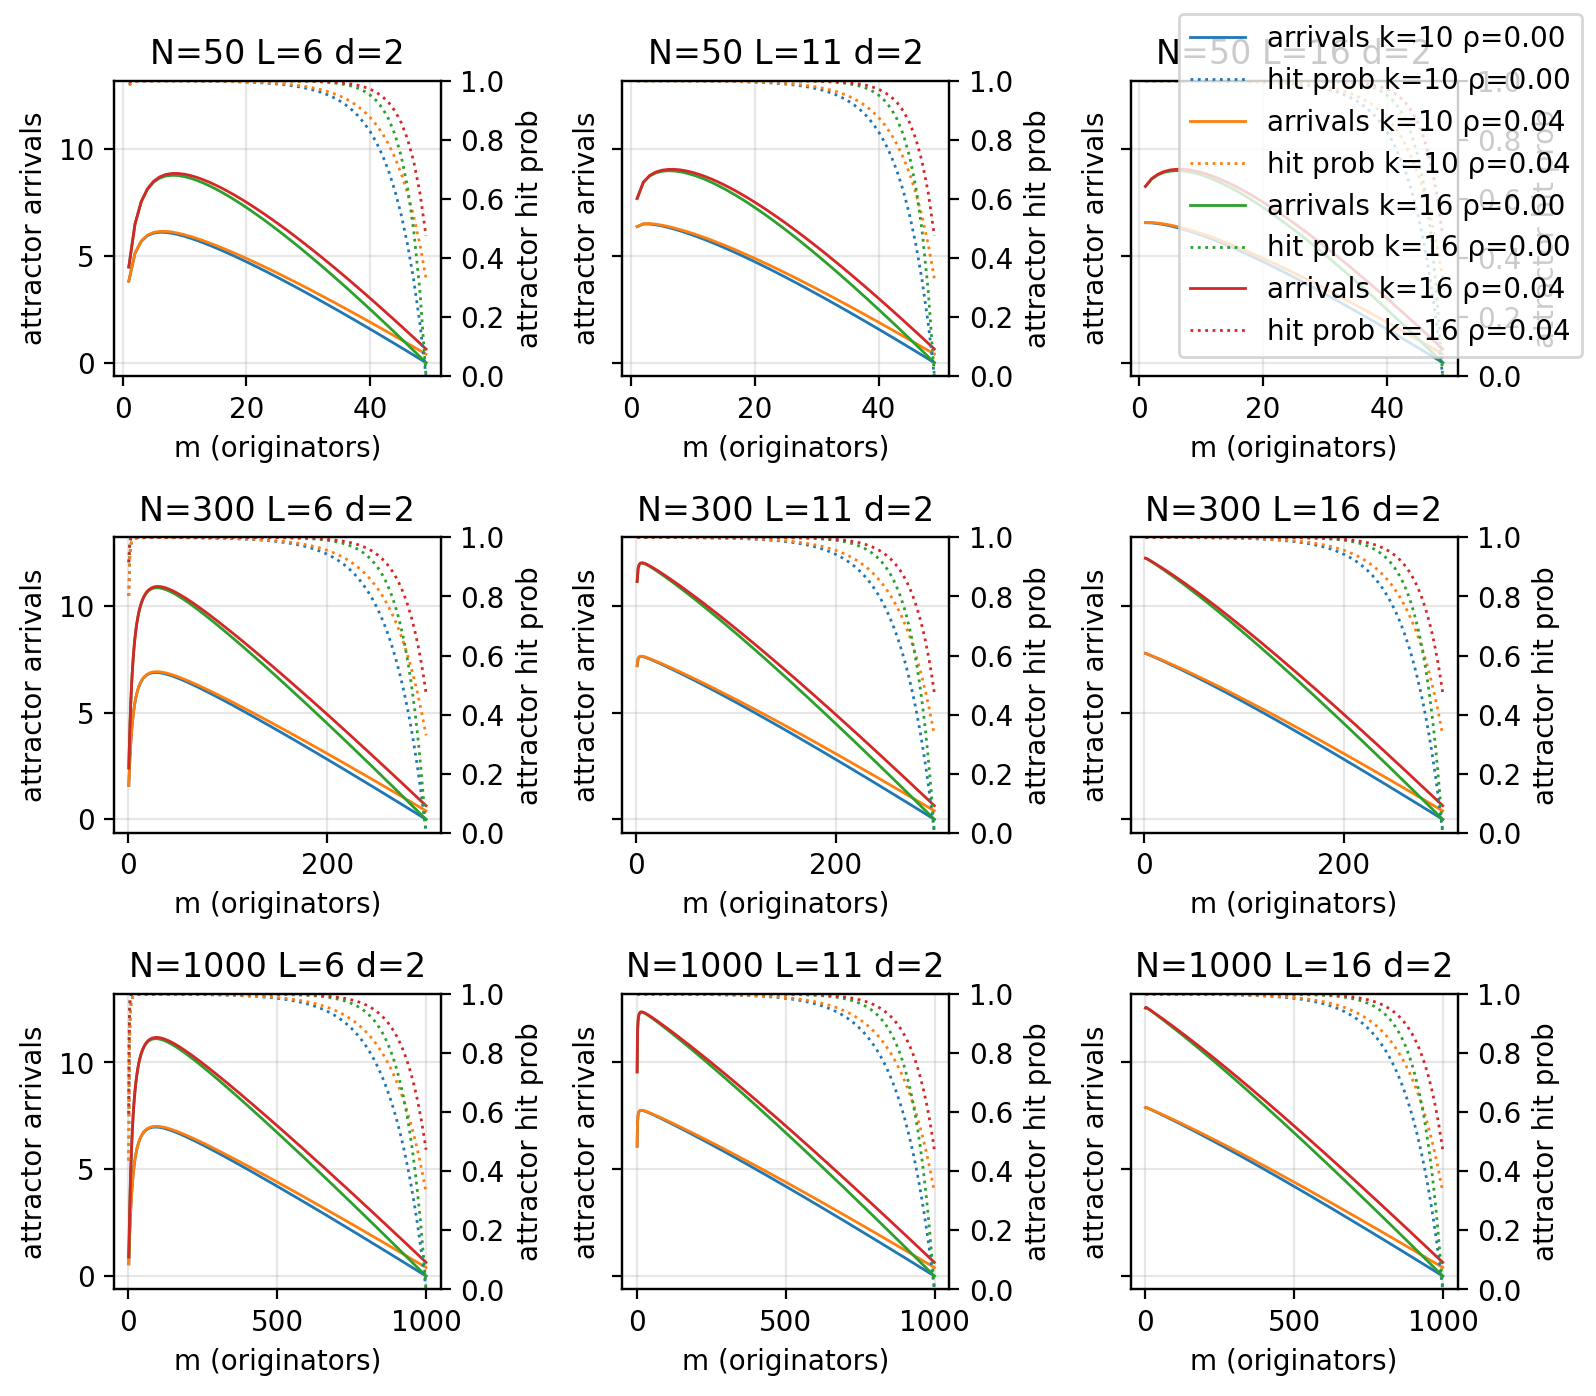

In [21]:
def plot_attractor_in_multi_origin(Ns, ks, Ls, rhos, d=2):
    fig, axes = plt.subplots(len(Ns), len(Ls), figsize=(8, 7), sharex=False, sharey=True)
    legend_handles = []
    legend_labels = []
    for i, N in enumerate(Ns):
        for j, L in enumerate(Ls):
            ax = axes[i, j]
            ax2 = ax.twinx()
            ax.set_title(f"N={N} L={L} d={d}")
            ax.set_xlabel("m (originators)")
            ax.set_ylabel("attractor arrivals")
            ax2.set_ylabel("attractor hit prob")
            ax2.set_ylim(0, 1)
            ax.grid(True, alpha=0.3)
            for k in ks:
                for rho in rhos:
                    ms = list(range(1, N))
                    results = [attractor_gossip(N=N, k=k, d=d, m=m, L=L, rho=rho) for m in ms]
                    options = f"k={k} ρ={rho:.2f}"
                    line1, = ax.plot(
                        ms,
                        [r["attractor_arrivals"] for r in results],
                        linewidth=1,
                        label=f"arrivals {options}" if (i == 0 and j == 0) else "_nolegend_",
                    )
                    line2, = ax2.plot(
                        ms,
                        [r["attractor_hit_prob"] for r in results],
                        linewidth=1,
                        linestyle=":",
                        label=f"hit prob {options}" if (i == 0 and j == 0) else "_nolegend_",
                    )
                    if i == 0 and j == 0:
                        legend_handles.extend([line1, line2])
                        legend_labels.extend([line1.get_label(), line2.get_label()])
    fig.legend(legend_handles, legend_labels, loc="upper right")
    fig.tight_layout(rect=[0, 0, 1, 1])
    plt.show()

plot_attractor_in_multi_origin(Ns=[50, 300, 1000], ks=[10, 16], Ls=[6, 11, 16], rhos=[0.0, 0.04])

The model suggests that for networks with N anywhere from zero up to a few thousands, sensible parameters are:

- $k \approx 10$ -- larger values reduce sideways spread and slightly increase the arrival load at the attractor
- $L \approx 11$ -- smaller values may not let the gossip survive enough hops to find a node with the attractor in its peer set
- $\rho \approx 0.04$ -- larger values increase the attractor arrival load, smaller values may cause nondelivery at large $m \lessapprox N$
- $d=2$ -- as covered earlier, 3 causes severe burstiness and 1 does not spread exponentially

Except for $d=2$, the mechanism is not sensitive to parameter tuning, of course.